In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv("customer_shopping_data.csv")

In [2]:
# Step 1: Exploratory Data Analysis (EDA)
print("\n--- Dataset Info ---")
df.info()
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB

--- Summary Statistics ---
       invoice_no customer_id  gender           age  category      quantity  \
count       99457       99457   99457  99457.000000     99457  99457.000000   
unique      99457       99457       2           NaN         8           NaN   
to

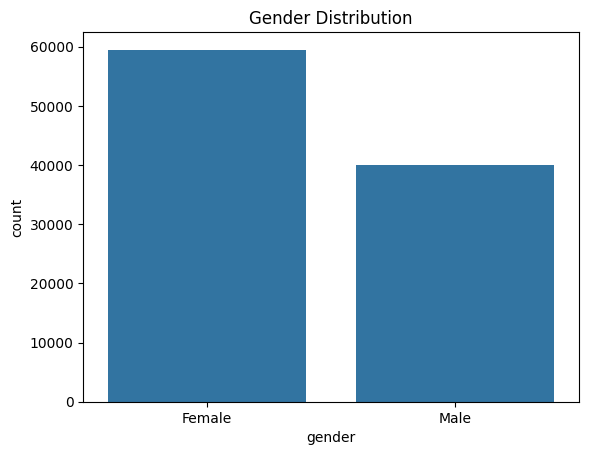

In [3]:
# Gender distribution
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

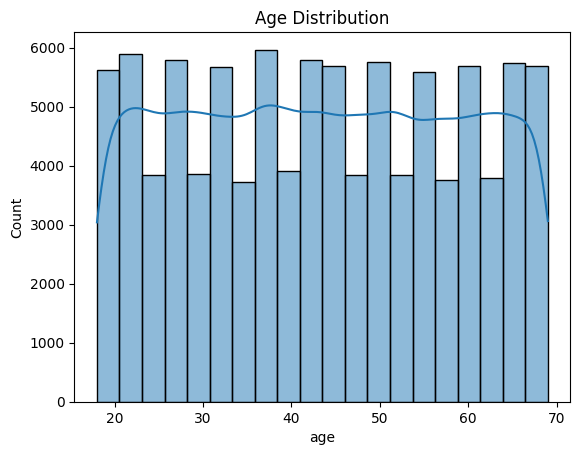

In [4]:
# Age distribution
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

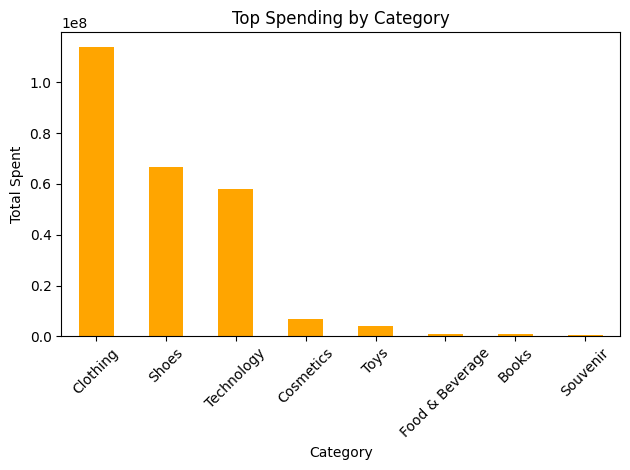

In [15]:
# Spending by top 10 categories
top_categories = df.groupby('category')['total_spent'].sum().sort_values(ascending=False).head(10)

# Plot
top_categories.plot(kind='bar', title="Top Spending by Category", color='orange')
plt.ylabel("Total Spent")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

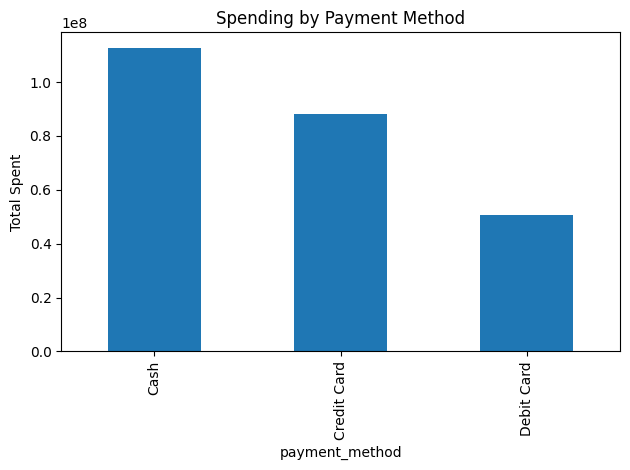

In [16]:
# Payment method spending
df.groupby('payment_method')['total_spent'].sum().plot(kind='bar', title="Spending by Payment Method")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.show()

In [7]:
# 2. Data Cleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True, errors='coerce')
df.dropna(subset=['invoice_date'], inplace=True)
df['total_spent'] = df['price'] * df['quantity']

In [8]:
# 3. Feature Engineering for Clustering
agg_df = df.groupby('customer_id').agg({
    'age': 'mean',
    'quantity': 'sum',
    'price': 'mean',
    'total_spent': 'sum'
}).reset_index()

In [9]:
# 4. Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(agg_df.drop(columns='customer_id'))

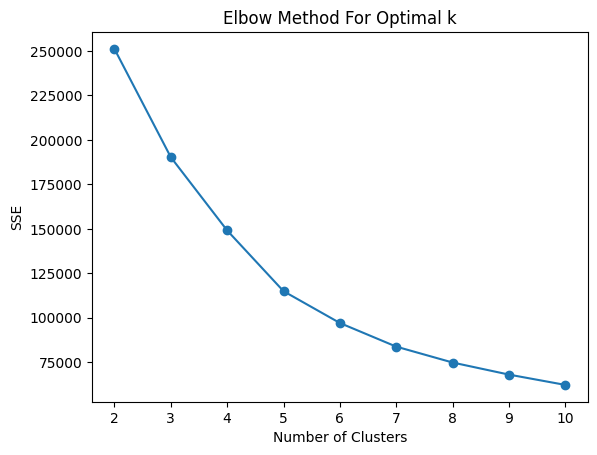

In [10]:
# 5. Elbow Method to find optimal k
sse = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(2, 11), sse, marker='o')
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [11]:
# 6. Apply KMeans with chosen k (e.g., 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
agg_df['cluster'] = kmeans.fit_predict(X_scaled)

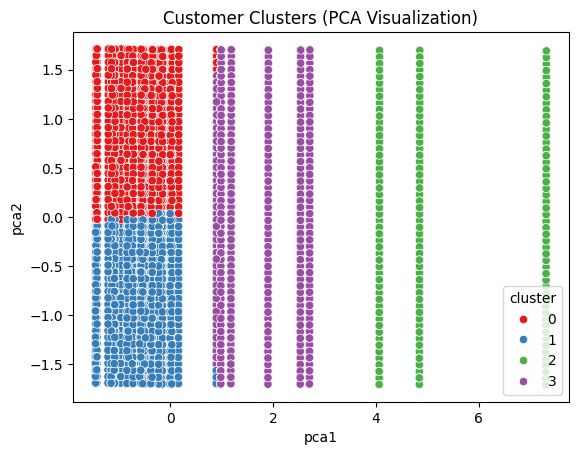

In [12]:
# 7. PCA for 2D Visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
agg_df['pca1'] = pca_features[:, 0]
agg_df['pca2'] = pca_features[:, 1]

sns.scatterplot(data=agg_df, x='pca1', y='pca2', hue='cluster', palette='Set1')
plt.title("Customer Clusters (PCA Visualization)")
plt.show()

In [13]:
# 8. Cluster Summary
cluster_summary = agg_df.groupby('cluster')[['age', 'quantity', 'price', 'total_spent']].mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
               age  quantity        price   total_spent
cluster                                                
0        56.433835  2.587282   278.142089    656.723320
1        30.435379  2.658399   274.424110    657.572349
2        43.434122  4.750685  3860.563151  18255.692466
3        43.437002  4.109961  1630.233812   6517.484745
